# **1. Perkenalan Dataset**


Dataset yang digunakan pada submission ini adalah [Crop Recommendation Dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset) yang bersumber dari [Kaggle](https://www.kaggle.com/).

Dataset ini memuat 7 fitur sebagai berikut:

1. N - rasio kandungan Nitrogen dalam tanah

2. P - rasio kandungan Phospor dalam tanah

3. K - rasio kandungan Kalium dalam tanah

4. temperature - suhu dalam derajat Celcius

5. humidity - presentase kelembaban

6. ph - nilai ph keasaman tanah

7. rainfall - curah hujan (mm)

Dari 7 fitur tersebut nantinya dapat diklasifikasikan jenis tanaman yang paling cocok untuk ditanam pada kondisi tanah tertentu.


# **2. Import Library**

Berikut adalah beberapa library yang dibutuhkan untuk analisis dan pemodelan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Dataset berupa berkas CSV sehingga dapat dimuat dengan menggunakan library pandas

In [2]:
dataset = pd.read_csv('../CropRecommendation_raw.csv')
dataset

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, dilakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## Statistik Deskriptif

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
dataset.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


Berdasarkan output statistik deskriptif, dataset terdiri dari 2.200 data dengan 8 variabel, yaitu tujuh fitur numerik (N, P, K, temperature, humidity, pH, dan rainfall) serta satu variabel kategorikal (label). Seluruh kolom memiliki jumlah data yang lengkap tanpa nilai yang hilang. Secara umum, rentang nilai pada setiap variabel menunjukkan variasi kondisi lingkungan yang cukup luas, sehingga dataset ini dapat merepresentasikan berbagai kondisi tanah dan iklim yang berbeda untuk kebutuhan analisis rekomendasi tanaman.

## Distribusi Data

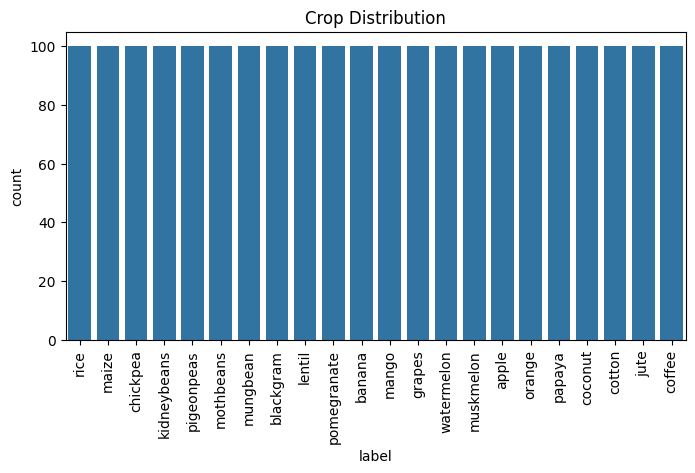

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=dataset)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

Dari output di atas, dapat diketahui bahwa dataset memiliki 22 label jenis tanaman dan memiliki sebaran data yang seimbang, yaitu masing-masing terdapat 100 data pada tiap label tanaman.

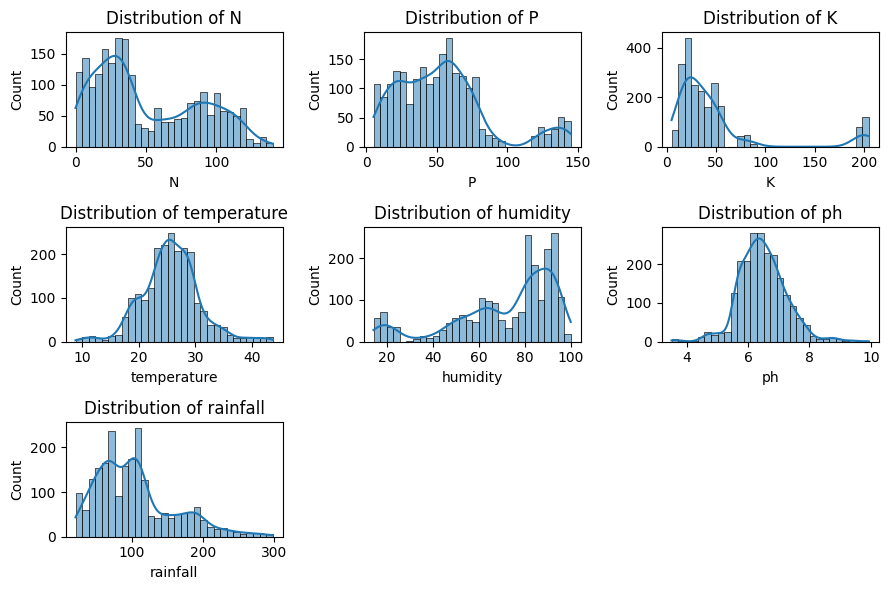

In [6]:
 
# Visualisasi distribusi data untuk fitur numerik
columns_to_plot = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
 
plt.figure(figsize=(9, 6))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.histplot(x=dataset[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
 
plt.tight_layout()
plt.show()

Berdasarkan visualisasi distribusi data, setiap variabel memiliki pola penyebaran yang berbeda. Variabel N, P, dan K menunjukkan distribusi yang relatif menyebar dengan beberapa konsentrasi nilai pada rentang tertentu, yang mengindikasikan variasi kandungan unsur hara tanah pada dataset. Variabel temperature cenderung memiliki distribusi yang mendekati normal dengan sebagian besar nilai berada pada kisaran sekitar 20–30°C. Variabel humidity menunjukkan konsentrasi data yang cukup tinggi pada nilai kelembapan menengah hingga tinggi. Nilai pH tanah sebagian besar berada pada rentang sekitar 5,5 hingga 7,5 yang menunjukkan kondisi tanah yang cenderung sedikit asam hingga netral. Sementara itu, distribusi rainfall menunjukkan penyebaran yang cukup luas dengan sebagian besar data berada pada kisaran curah hujan rendah hingga menengah. Secara keseluruhan, distribusi ini menunjukkan bahwa dataset mencakup variasi kondisi lingkungan yang cukup beragam, yang dapat mendukung analisis dalam menentukan rekomendasi tanaman yang sesuai.


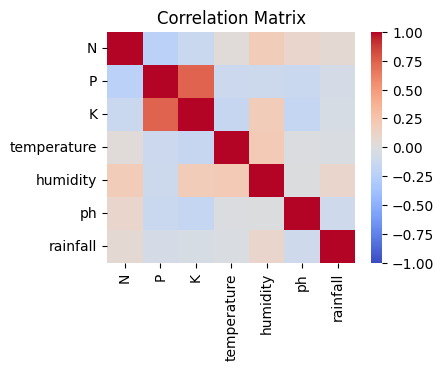

In [7]:
# Visualisasi korelasi antar variabel numerik
plt.figure(figsize=(4, 3))
correlation_matrix = dataset[columns_to_plot].corr()
 
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

Berdasarkan visualisasi correlation matrix, sebagian besar variabel pada dataset memiliki tingkat korelasi yang relatif rendah hingga sedang satu sama lain. Hal ini menunjukkan bahwa setiap fitur memberikan informasi yang berbeda dan tidak saling bergantung secara kuat.

# **5. Data Preprocessing**

Pada tahap ini dilakukan pra-pemrosesan data untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

## Split Fitur dan Target

In [8]:
X = dataset.drop("label", axis=1)
y = dataset["label"]

## Label Encoding

In [9]:
le = LabelEncoder()
y = le.fit_transform(y)

In [10]:
# Tampilkan hasil encodingnya
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")

apple -> 0
banana -> 1
blackgram -> 2
chickpea -> 3
coconut -> 4
coffee -> 5
cotton -> 6
grapes -> 7
jute -> 8
kidneybeans -> 9
lentil -> 10
maize -> 11
mango -> 12
mothbeans -> 13
mungbean -> 14
muskmelon -> 15
orange -> 16
papaya -> 17
pigeonpeas -> 18
pomegranate -> 19
rice -> 20
watermelon -> 21


## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scaling Data

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)